# Constrained sampling on the ball: anchored Langevin with a **state-dependent** $J$

Target restricted to the Euclidean ball

$$K=\{x\in\mathbb R^3:\ \lVert x\rVert_2^2\le 1\},\qquad
\pi(x)\;\propto\;e^{-U(x)}\,\mathbf 1_K(x),$$

with the same two targets and the same figure set as `anchored_langevin_multivariate.ipynb`
($W_1$ per coordinate, 2D contours, sweep over the skew strength, fixed-physical-time control), now
comparing $J=0$ against a state-dependent $J_s(x)$. The constant skew $J_a$ is **excluded**: it violates
the boundary condition below, and `anchored_langevin_paper_J.ipynb` already measures what that costs.

## State dependence changes the invariance condition

For constant skew $J$ the extra stationary flux was $J\nabla\varphi$ with $\varphi=e^{-U_0}$, and
$\nabla\!\cdot(J\nabla\varphi)=0$ followed from antisymmetry alone. Once $J$ varies with $x$ that argument
fails and the correct divergence-free flux is $\mathcal F_i=\sum_j\partial_j\bigl(J_{ij}\varphi\bigr)$,
whose divergence $\sum_{ij}\partial_i\partial_j(J_{ij}\varphi)$ vanishes because $J_{ij}\varphi$ is
antisymmetric in $(i,j)$ while $\partial_i\partial_j$ is symmetric. Dividing by $\pi$ gives the
**anchored, state-dependent-$J$ dynamics**

$$\boxed{\;dX_t=e^{\Delta(X_t)}\Bigl[-\bigl(I+J(X_t)\bigr)\nabla U_0(X_t)+\nabla\!\cdot J(X_t)\Bigr]dt
\;+\;\sqrt2\,e^{\Delta(X_t)/2}\,dW_t\;}$$

with $(\nabla\!\cdot J)_i=\sum_j\partial_j J_{ij}$ and $\Delta=U-U_0$ as before. The correction term
$\nabla\!\cdot J$ is the price of state dependence; it vanishes for constant $J$, recovering the previous
notebook.

## The constraint adds a *second* condition, on the boundary

Sampling on $K$ by projection means the boundary must carry no net probability flux. The reversible part
already satisfies this, but the skew drift $-J\nabla U_0e^{\Delta}$ must be **tangential** to $\partial K$,
i.e.

$$J(x)\,\nu(x)=0\quad\text{for }x\in\partial K,\qquad \nu(x)=x/\lVert x\rVert .$$

Otherwise the skew term pushes probability into the wall, the projection absorbs it, and the stationary law
is distorted — a bias no amount of stepsize refinement removes.

**The field used here:**

| | $J(x)$ | $\nabla\!\cdot J$ | $J(x)\nu(x)$ on $\partial K$ |
|---|---|---|---|
| state-dependent (axial) | $J_s(x)w=s\,(x\times w)$ | $0$ | $s\,(x\times x)=0$ — **satisfied identically** |

The axial (cross-product) field is the natural skew for a ball: its orbits are rotations about the axis
through $x$, which are exactly the level sets of $\lVert x\rVert$. It is also divergence-free, so the
correction term vanishes and the implemented update needs no extra gradient.
Both claims are checked numerically below rather than taken on faith.

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import wasserstein_distance, ks_2samp

In [2]:
# -----------------------------
# Settings
# -----------------------------
d        = 3
R        = 1.0          # K = {||x||_2 <= 1}
N        = 5000
max_iter = 3000
eta      = 1e-3
delta    = 0.1          # anchor smoothing
x_start  = 0.3
SEED     = 1006

# --- skew strengths, chosen by the tuning study in Experiments 2 and 3 (not guessed) ---
S_FREE   = 6.0          # largest constant s whose stationary accuracy still ties J = 0
S_BEST   = 12.0         # constant s with the fastest transient (pays a small stationary price)
S0, KANN = 20.0, 800    # annealed schedule s(k) = S0 * max(0, 1 - k/KANN)
SEEDS    = [11, 22, 33, 44, 55, 66, 77]   # every W1 curve below is a mean over these
EVERY    = 5            # W1 is recorded every EVERY iterations
TUNE_ITERS = 2000       # horizon for the multi-seed tuning runs (stationary well before this)

SCALES = [0.5, 1.0, 2.0]
RHO    = 0.6

def make_L(dim, scales, rho):
    Dm = np.diag(scales)
    Cm = np.full((dim, dim), rho); np.fill_diagonal(Cm, 1.0)
    return np.linalg.cholesky(Dm @ Cm @ Dm)

L3 = make_L(d, SCALES, RHO)
Minv = torch.tensor(np.linalg.inv(L3))
print("Sigma =\n", np.round(L3 @ L3.T, 3))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]


In [3]:
# -----------------------------
# The two skew fields
# -----------------------------
@torch.no_grad()
def skew_apply(x, g, s):
    # J_s(x) g = s (x cross g)
    return torch.zeros_like(g) if s == 0.0 else s * torch.cross(x, g, dim=1)

# ---- check 1: is J_s divergence-free?  (needs sum_j d_j J_ij = 0)
xt = torch.randn(6, d, requires_grad=True)
div = torch.zeros(6, d)
for i in range(d):
    for j in range(d):
        e = torch.zeros(d); e[j] = 1.0
        Jij = torch.cross(xt, e.expand(6, d), dim=1)[:, i]     # (J(x) e_j)_i
        div[:, i] += torch.autograd.grad(Jij.sum(), xt, retain_graph=True)[0][:, j]
print("axial J: max |div J| = {:.2e}   -> correction term is exactly zero".format(float(div.abs().max())))

# ---- check 2: boundary condition J(x) nu(x) = 0 on ||x|| = 1
xb = torch.randn(2000, d); xb = xb / xb.norm(dim=1, keepdim=True)
print("axial    J(x) nu(x) : max |.| = {:.2e}   -> tangential".format(
    float((S0 * torch.cross(xb, xb, dim=1)).abs().max())))
print("(a constant skew would give |J n| ~ 1 here, which is why it is excluded)")

axial J: max |div J| = 0.00e+00   -> correction term is exactly zero
axial    J(x) nu(x) : max |.| = 5.55e-16   -> tangential
(a constant skew would give |J n| ~ 1 here, which is why it is excluded)


In [4]:
# -----------------------------
# Targets (same two as the multivariate notebook), now restricted to K
#   "ell": U = ||M x||_2      "l1": U = ||M x||_1
# Anchors are the same smoothings; U is never differentiated.
# -----------------------------
def build_target(kind):
    if kind == "ell":
        @torch.no_grad()
        def U(x):  return torch.norm(x @ Minv.T, dim=1)
        @torch.no_grad()
        def U0(x): return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv
    else:
        @torch.no_grad()
        def U(x):  return torch.sum(torch.abs(x @ Minv.T), dim=1)
        @torch.no_grad()
        def U0(x): return torch.sum(torch.sqrt((x @ Minv.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ Minv
    return U, U0, gU0

# reference samples: draw from the unconstrained target, keep those inside K (rejection, as in the
# Gaussian notebook)
def sample_target(kind, n, rng):
    out = []
    while len(out) < n:
        if kind == "ell":
            r = rng.gamma(d, 1.0, n)
            u = rng.normal(size=(n, d)); u /= np.linalg.norm(u, axis=1, keepdims=True)
            y = r[:, None] * u
        else:
            y = rng.laplace(0.0, 1.0, size=(n, d))
        z = y @ L3.T
        out.extend(z[np.linalg.norm(z, axis=1) <= R].tolist())
    return np.array(out[:n])

@torch.no_grad()
def proj_ball(x):
    n = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(R / n, max=1.0)

In [5]:
# -----------------------------
# Projected anchored Langevin with the skew field
#   x <- P_K( x - eta * e^Delta (I + J(x)) gradU0  + sqrt(2 eta) e^{Delta/2} xi )
# (the div J correction is zero for this field, verified above)
#
# The strength may depend on the iteration.  A "spec" is either
#   a float          -> constant s
#   ("lin", s0, K)   -> s(k) = s0 * max(0, 1 - k/K), annealed to zero by iteration K
# Every fixed s leaves pi invariant (div J = 0 and J nu = 0 hold for every s), so a schedule
# is a non-homogeneous chain each of whose steps preserves the same target.  Nothing about
# the invariant law depends on s; only the rate does.
# -----------------------------
def strength(spec, k):
    if isinstance(spec, tuple):
        return spec[1] * max(0.0, 1.0 - k / spec[2])
    return float(spec)

def spec_label(spec):
    if isinstance(spec, tuple):
        return "annealed $s_0={:.0f}$, K={}".format(spec[1], spec[2])
    return "$J = 0$" if spec == 0.0 else "constant $s={:.0f}$".format(spec)

@torch.no_grad()
def run_chain(kind_target, spec, ref=None, eta=eta, n_steps=max_iter, N=N,
              seed=SEED, track=True, every=EVERY):
    U, U0, gU0 = build_target(kind_target)
    torch.manual_seed(seed)
    x = proj_ball(torch.full((N, d), x_start))
    it, W = [], []
    for k in range(n_steps):
        s = strength(spec, k)
        Delta = U(x) - U0(x)
        g = gU0(x) * torch.exp(Delta).unsqueeze(1)
        x = proj_ball(x - eta * (g + skew_apply(x, g, s))
                      + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x))
        if track and (k + 1) % every == 0:
            xn = x.numpy()
            it.append(k + 1)
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), np.array(it), (np.array(W) if track else None)

def on_boundary(X):
    return float(np.mean(np.linalg.norm(X, axis=1) > 0.999 * R))

def w1_floor(ref, kind, rng, reps=6):
    return [float(np.mean([wasserstein_distance(ref[:, i], sample_target(kind, len(ref), rng)[:, i])
                           for _ in range(reps)])) for i in range(d)]

def ensemble(kind, spec, ref, seeds=SEEDS, n_steps=TUNE_ITERS):
    # one coordinate-averaged W1 curve per seed, plus the terminal ensemble of the last seed
    C, X, it = [], None, None
    for sd in seeds:
        X, it, W = run_chain(kind, spec, ref=ref, seed=sd, n_steps=n_steps)
        C.append(W.mean(axis=1))
    return it, np.array(C), X

def tau(it, curve, eps):
    # iterations needed to reach accuracy eps and stay there
    bad = np.where(curve > eps)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return np.nan if j >= len(it) else float(it[j])

def tau_stats(it, C, eps):
    v = np.array([tau(it, c, eps) for c in C], dtype=float)
    return float(np.nanmean(v)), float(np.nanstd(v))

## Experiment 1 — reference samples and the sampling floor

Everything below is measured against rejection samples from the constrained target, and against the
**sampling floor**: the $W_1$ between two independent exact draws of the same size. No sampler can beat
it, so a scheme sitting on the floor is finished converging and comparisons there measure nothing.

In [6]:
TARGETS = {"ell": "Target A: elliptical Laplace on K", "l1": "Target B: correlated $\\ell_1$ Laplace on K"}
rng = np.random.default_rng(SEED)
refs, floors = {}, {}
for kind in TARGETS:
    refs[kind] = sample_target(kind, N, rng)
    floors[kind] = w1_floor(refs[kind], kind, rng)
    print("{:<5} floor per coord {}   mean {:.4f}   target boundary mass {:.4f}".format(
        kind, np.round(floors[kind], 4), float(np.mean(floors[kind])), on_boundary(refs[kind])))

ell   floor per coord [0.0083 0.0122 0.0103]   mean 0.0103   target boundary mass 0.0018
l1    floor per coord [0.011  0.0136 0.0124]   mean 0.0123   target boundary mass 0.0010


## Experiment 2 — tune the strength $s$

$J_s$ cannot change *where* the chain ends up, only *how fast* it gets there. So the tuning target is a
rate, and the two honest ways to read one are

* $W_1$ at a **fixed iteration budget** in the transient, and
* $\tau(\varepsilon)$, the **iterations needed to reach accuracy $\varepsilon$** and stay there.

Both are averaged over 7 seeds, because a single run's $W_1$ curve wiggles by more than the differences
worth reporting. The threshold $\varepsilon$ must sit safely above the stationary value: near the floor the
curve crosses it repeatedly and $\tau$ becomes a noise statistic rather than a rate.

In [7]:
S_GRID = [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0]
EPS_T = 0.03
IT_BUDGET = 300

tuning = {}
for kind in TARGETS:
    tuning[kind] = {}
    print("\n### {}   floor {:.4f}".format(kind, float(np.mean(floors[kind]))))
    print("{:<8}{:>22}{:>10}{:>24}{:>24}".format("s", "tau(0.03) mean+-sd", "speed-up", "W1 @ 300 iters", "W1 @ stationarity"))
    print("-" * 90)
    base = None
    for s in S_GRID:
        it, C, X = ensemble(kind, s, refs[kind])
        m, sd_ = C.mean(axis=0), C.std(axis=0)
        tm, ts = tau_stats(it, C, EPS_T)
        if base is None: base = tm
        i_b = int(IT_BUDGET / EVERY) - 1
        tuning[kind][s] = {"it": it, "C": C, "tau": (tm, ts), "bnd": on_boundary(X)}
        print("{:<8}{:>22}{:>10}{:>24}{:>24}".format(
            s, "{:.0f} +- {:.0f}".format(tm, ts), "{:.2f}x".format(base / tm),
            "{:.4f} +- {:.4f}".format(m[i_b], sd_[i_b]),
            "{:.4f} +- {:.4f}".format(m[-1], sd_[-1])))


### ell   floor 0.0103
s           tau(0.03) mean+-sd  speed-up          W1 @ 300 iters       W1 @ stationarity
------------------------------------------------------------------------------------------


0.0                  624 +- 27     1.00x        0.0984 +- 0.0044        0.0126 +- 0.0018


2.0                  560 +- 17     1.11x        0.0867 +- 0.0046        0.0129 +- 0.0021


4.0                  446 +- 17     1.40x        0.0627 +- 0.0044        0.0131 +- 0.0021


6.0                  375 +- 15     1.66x        0.0444 +- 0.0036        0.0132 +- 0.0018


...

8.0                  259 +- 10     2.31x        0.0204 +- 0.0021        0.0147 +- 0.0036


10.0                 220 +- 10     2.72x        0.0165 +- 0.0020        0.0151 +- 0.0022


12.0                  195 +- 7     3.07x        0.0154 +- 0.0024        0.0162 +- 0.0031


16.0                 174 +- 13     3.44x        0.0186 +- 0.0023        0.0210 +- 0.0015


20.0               1902 +- 116     0.31x        0.0253 +- 0.0015        0.0277 +- 0.0016


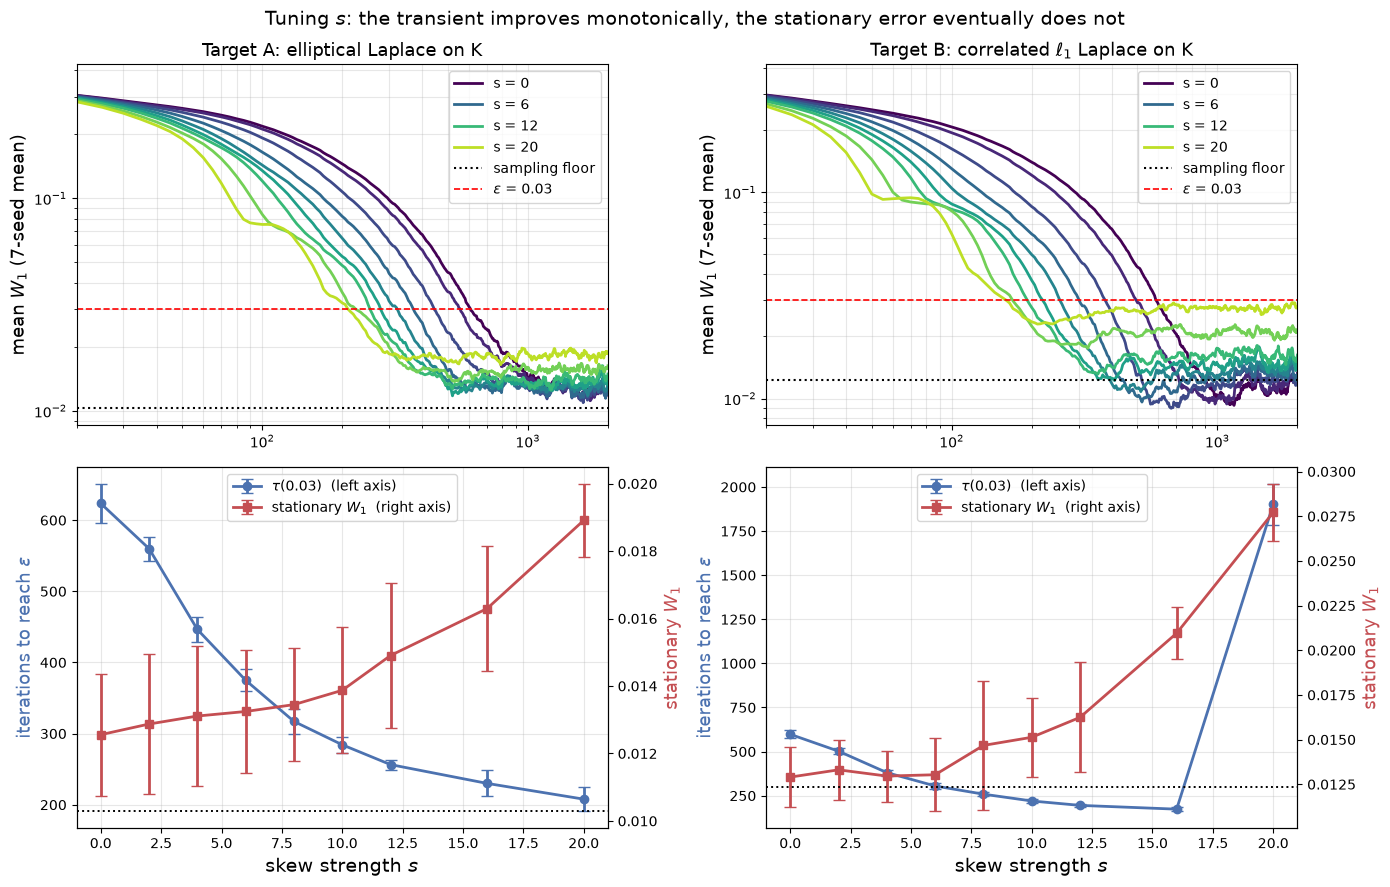

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for col, (kind, title) in enumerate(TARGETS.items()):
    ax = axes[0, col]
    cmap = plt.cm.viridis(np.linspace(0, 0.9, len(S_GRID)))
    for c, s in zip(cmap, S_GRID):
        r = tuning[kind][s]
        ax.plot(r["it"], r["C"].mean(axis=0), linewidth=2, color=c,
                label="s = {:.0f}".format(s) if s in (0.0, 6.0, 12.0, 20.0) else None)
    ax.axhline(float(np.mean(floors[kind])), color="k", linestyle=":", linewidth=1.5, label="sampling floor")
    ax.axhline(EPS_T, color="r", linestyle="--", linewidth=1.2, label=r"$\varepsilon$ = 0.03")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(20, TUNE_ITERS)
    ax.set_ylabel("mean $W_1$ (7-seed mean)", fontsize=13)
    ax.set_title(title, fontsize=13); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=10)

    ax = axes[1, col]
    tt = [tuning[kind][s]["tau"][0] for s in S_GRID]
    te = [tuning[kind][s]["tau"][1] for s in S_GRID]
    ax.errorbar(S_GRID, tt, yerr=te, marker="o", linewidth=2, capsize=4, color="#4C72B0",
                label=r"$\tau(0.03)$  (left axis)")
    ax.set_xlabel("skew strength $s$", fontsize=14)
    ax.set_ylabel(r"iterations to reach $\varepsilon$", fontsize=13, color="#4C72B0")
    ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    st = [tuning[kind][s]["C"].mean(axis=0)[-1] for s in S_GRID]
    se = [tuning[kind][s]["C"].std(axis=0)[-1] for s in S_GRID]
    ax2.errorbar(S_GRID, st, yerr=se, marker="s", linewidth=2, capsize=4, color="#C44E52",
                 label="stationary $W_1$  (right axis)")
    ax2.axhline(float(np.mean(floors[kind])), color="k", linestyle=":", linewidth=1.4)
    ax2.set_ylabel("stationary $W_1$", fontsize=13, color="#C44E52")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=10, loc="upper center")
fig.suptitle("Tuning $s$: the transient improves monotonically, the stationary error eventually does not",
             fontsize=14)
plt.tight_layout()
plt.savefig("figures/ball_tuning.pdf", dpi=300, bbox_inches="tight")
plt.show()

The two curves in the lower panels pull in opposite directions, and that tension is the whole tuning
problem:

* $\tau(\varepsilon)$ **falls steeply** with $s$ and then flattens — the circulation is doing real work,
  and past $s\approx12$–$16$ there is little left to gain.
* the **stationary** $W_1$ is flat up to $s\approx6$ and then climbs.

The second curve is *not* a failure of invariance. $\pi$ is invariant for every $s$; what degrades is the
**discretization**. $J_s(x)g$ is tangential to the sphere through $x$, but the Euler step follows the
tangent *line*, so each step overshoots by $O(\eta^2\lVert J_s\nabla U_0\rVert^2)=O(\eta^2s^2)$ and is
projected back. That error grows with $s$ and must shrink with $\eta$ — Experiment 4 checks exactly that.

So a *constant* $s$ forces a compromise: $s=6$ is free but leaves speed on the table, $s=12$ is fast but
pays at stationarity. The next experiment removes the compromise.

## Experiment 3 — anneal $s$, and get both

The discretization penalty is paid *per step*, at whatever $s$ that step uses; the acceleration is only
needed while the chain is still far from $\pi$. Those are different phases, so the strength need not be
constant. Take

$$s(k)=s_0\max\!\Bigl(0,\;1-\tfrac{k}{K}\Bigr),$$

large while the chain is travelling and zero once it has arrived. This is legitimate for the same reason
the constant case is: $\nabla\!\cdot J_s=0$ and $J_s(x)\nu(x)=0$ hold for **every** value of $s$, so every
step of the schedule preserves the same $\pi$ — the chain is non-homogeneous but its invariant law never
moves. After iteration $K$ the scheme *is* $J=0$, so it inherits $J=0$'s stationary accuracy exactly.

In [9]:
SPECS = [0.0, S_FREE, S_BEST, ("lin", 12.0, 800), ("lin", S0, 400), ("lin", S0, KANN)]
EPSL = [0.05, 0.035, 0.03]

final = {}
for kind in TARGETS:
    final[kind] = {}
    print("\n### {}   floor {:.4f}   target boundary mass {:.4f}".format(
        kind, float(np.mean(floors[kind])), on_boundary(refs[kind])))
    hdr = "{:<26}" + "{:>20}" * len(EPSL) + "{:>22}{:>22}{:>9}"
    print(hdr.format("scheme", *["tau({})".format(e) for e in EPSL],
                     "W1 @ 300 iters", "W1 @ stationarity", "bnd"))
    print("-" * 145)
    base = {}
    for spec in SPECS:
        it, C, X = ensemble(kind, spec, refs[kind])
        m, sd_ = C.mean(axis=0), C.std(axis=0)
        cells = []
        for e in EPSL:
            tm, ts = tau_stats(it, C, e)
            if spec == 0.0: base[e] = tm
            cells.append("{:.0f}+-{:.0f} ({:.1f}x)".format(tm, ts, base[e] / tm))
        i_b = int(IT_BUDGET / EVERY) - 1
        final[kind][spec_label(spec)] = {"it": it, "C": C, "x": X}
        print(hdr.format(spec_label(spec).replace("$", ""), *cells,
                         "{:.4f}+-{:.4f}".format(m[i_b], sd_[i_b]),
                         "{:.4f}+-{:.4f}".format(m[-1], sd_[-1]),
                         "{:.3f}".format(on_boundary(X))))


### ell   floor 0.0103   target boundary mass 0.0018
scheme                               tau(0.05)          tau(0.035)           tau(0.03)        W1 @ 300 iters     W1 @ stationarity      bnd
-------------------------------------------------------------------------------------------------------------------------------------------------


J = 0                           474+-10 (1.0x)      571+-16 (1.0x)      624+-27 (1.0x)        0.0984+-0.0044        0.0126+-0.0018    0.063


constant s=6                    286+-10 (1.7x)      349+-14 (1.6x)      375+-15 (1.7x)        0.0444+-0.0036        0.0132+-0.0018    0.057


constant s=12                    196+-9 (2.4x)       245+-8 (2.3x)       256+-7 (2.4x)        0.0221+-0.0028        0.0149+-0.0021    0.064


annealed s_0=12, K=800          208+-14 (2.3x)      264+-12 (2.2x)      286+-13 (2.2x)        0.0257+-0.0034        0.0125+-0.0018    0.063


...

constant s=6                    241+-10 (1.9x)      289+-18 (1.9x)      305+-19 (2.0x)        0.0304+-0.0040        0.0130+-0.0021    0.050


constant s=12                    158+-5 (3.0x)       184+-5 (3.0x)       195+-7 (3.1x)        0.0154+-0.0024        0.0162+-0.0031    0.057


annealed s_0=12, K=800           169+-4 (2.8x)       199+-8 (2.8x)      211+-10 (2.8x)        0.0164+-0.0021        0.0131+-0.0018    0.051


annealed s_0=20, K=400           125+-0 (3.8x)       146+-6 (3.8x)       163+-7 (3.7x)        0.0129+-0.0014        0.0131+-0.0017    0.051


annealed s_0=20, K=800           117+-2 (4.0x)       141+-8 (4.0x)       159+-8 (3.8x)        0.0157+-0.0018        0.0131+-0.0017    0.051


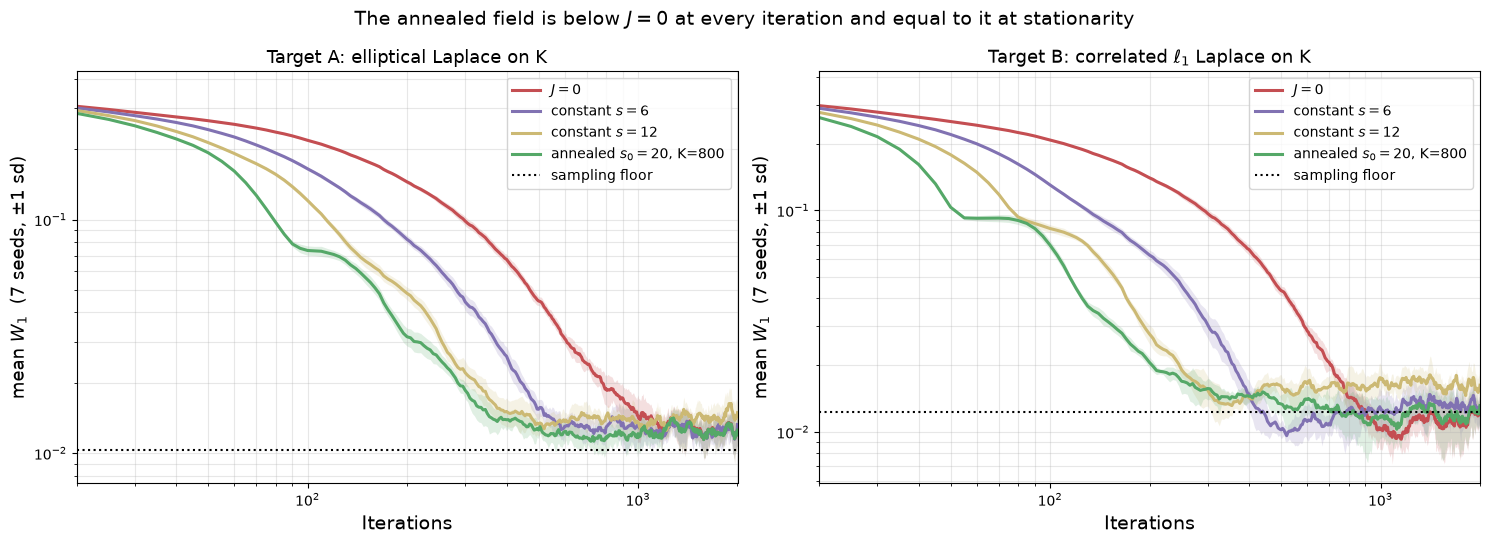

In [10]:
SHOW = ["$J = 0$", "constant $s=6$", "constant $s=12$", "annealed $s_0=20$, K=800"]
CBAR = {"$J = 0$": "#C44E52", "constant $s=6$": "#8172B2",
        "constant $s=12$": "#CCB974", "annealed $s_0=20$, K=800": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (kind, title) in zip(axes, TARGETS.items()):
    for lab in SHOW:
        r = final[kind][lab]
        m, sd_ = r["C"].mean(axis=0), r["C"].std(axis=0)
        ax.plot(r["it"], m, linewidth=2.2, color=CBAR[lab], label=lab)
        ax.fill_between(r["it"], m - sd_, m + sd_, color=CBAR[lab], alpha=0.18, linewidth=0)
    ax.axhline(float(np.mean(floors[kind])), color="k", linestyle=":", linewidth=1.5, label="sampling floor")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(20, TUNE_ITERS)
    ax.set_xlabel("Iterations", fontsize=14)
    ax.set_ylabel("mean $W_1$  (7 seeds, $\\pm$1 sd)", fontsize=13)
    ax.set_title(title, fontsize=13); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=10)
fig.suptitle("The annealed field is below $J=0$ at every iteration and equal to it at stationarity",
             fontsize=14)
plt.tight_layout()
plt.savefig("figures/ball_anneal.pdf", dpi=300, bbox_inches="tight")
plt.show()

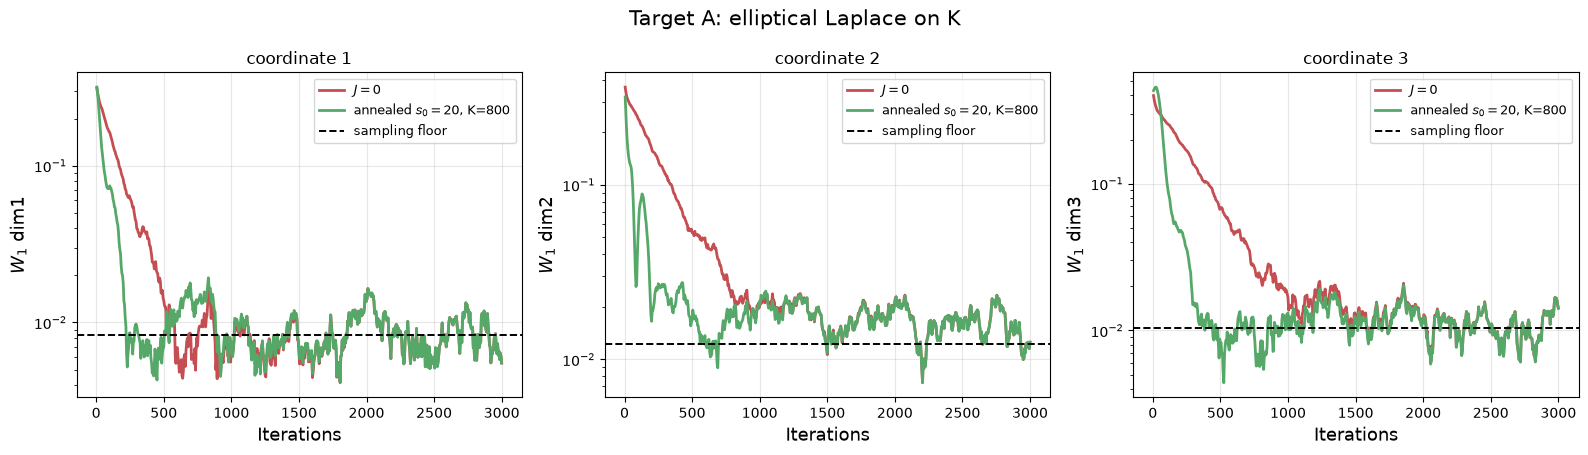

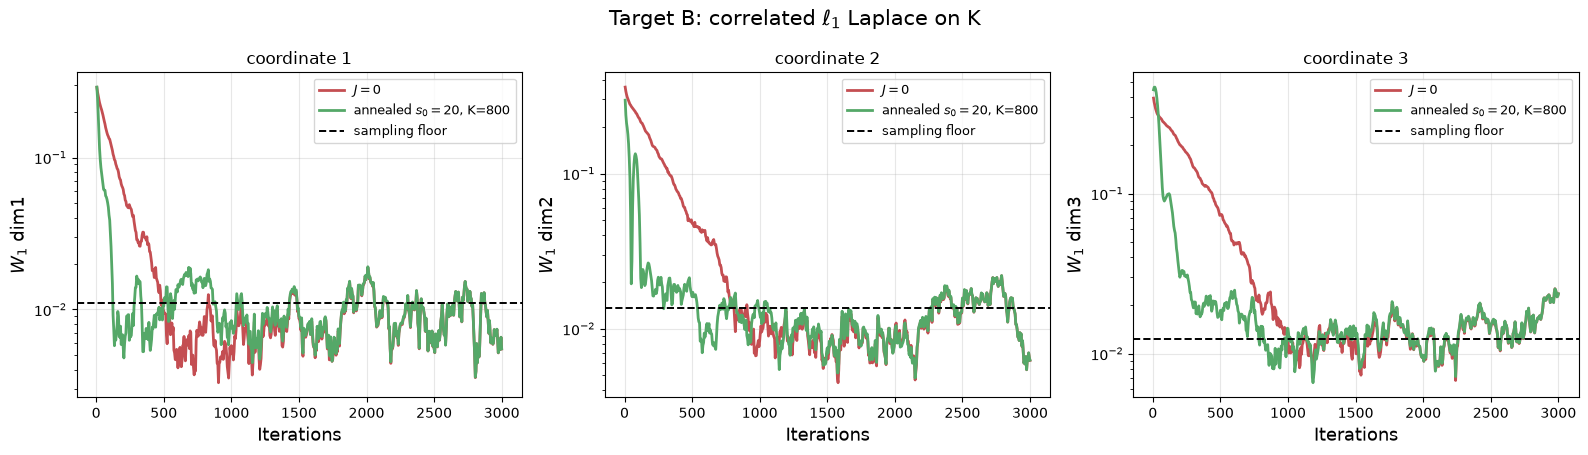

In [11]:
# per-coordinate view of the head-to-head, and the terminal densities
BEST = "annealed $s_0=20$, K=800"
for kind, title in TARGETS.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    for i, ax in enumerate(axes):
        for lab in ["$J = 0$", BEST]:
            _, it, W = run_chain(kind, 0.0 if lab == "$J = 0$" else ("lin", S0, KANN),
                                 ref=refs[kind], seed=SEEDS[0])
            ax.plot(it, W[:, i], linewidth=2, color=CBAR[lab], label=lab)
        ax.axhline(floors[kind][i], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
        ax.set_yscale("log"); ax.set_xlabel("Iterations", fontsize=13)
        ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=13)
        ax.set_title("coordinate {}".format(i + 1), fontsize=12)
        ax.grid(alpha=0.3); ax.legend(fontsize=9)
    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.savefig("figures/ball_w1_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

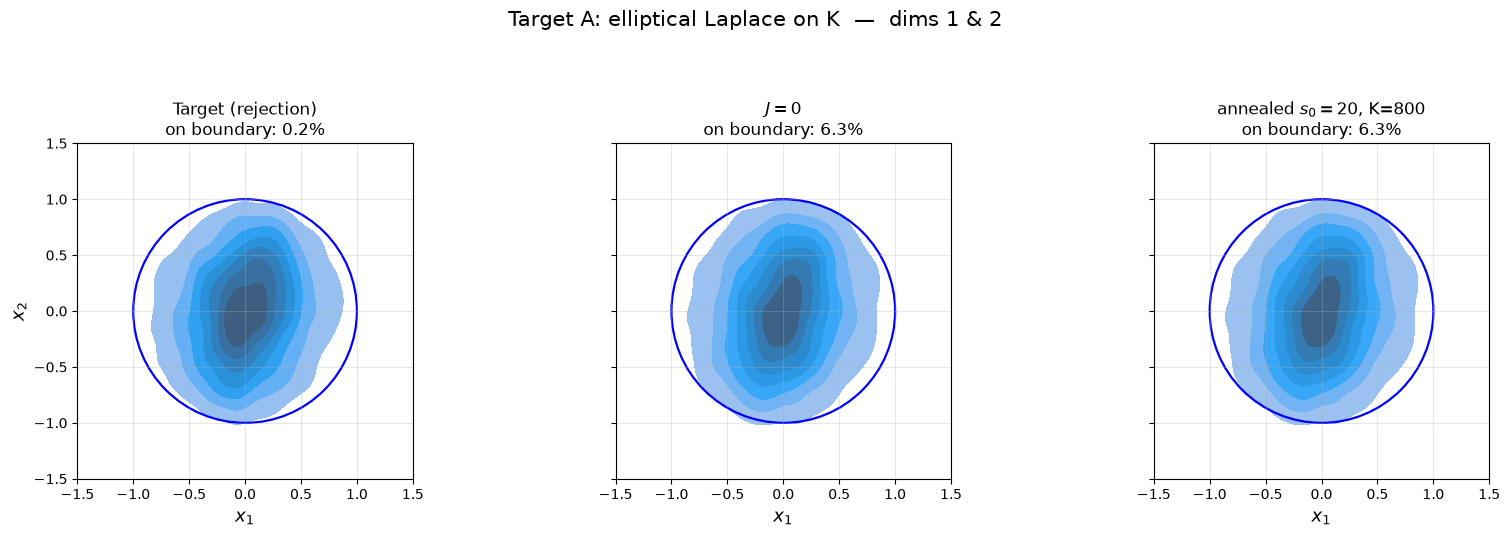

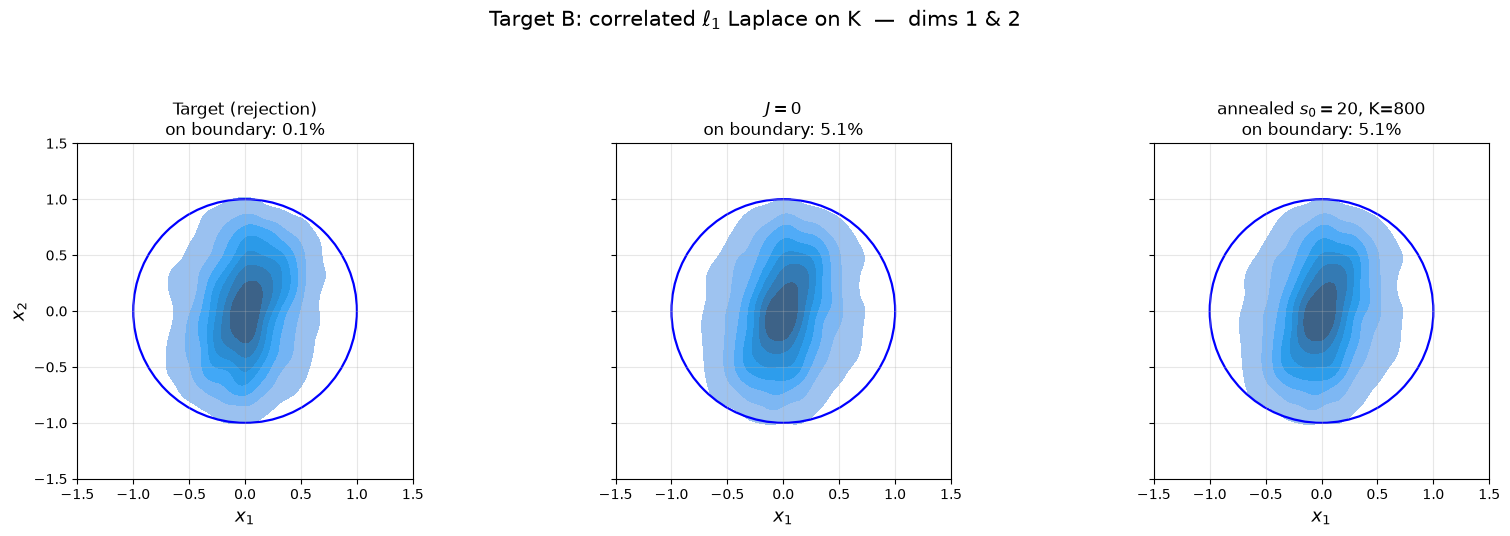

In [12]:
for kind, title in TARGETS.items():
    panels = [("Target (rejection)", refs[kind])] + [(lab, final[kind][lab]["x"]) for lab in ["$J = 0$", BEST]]
    fig, axes = plt.subplots(1, len(panels), figsize=(5.6 * len(panels), 5), sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
        ax.add_patch(Circle((0, 0), R, edgecolor="b", facecolor="none", linewidth=1.6))
        ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
        ax.set_title("{}\non boundary: {:.1%}".format(name, on_boundary(X)), fontsize=12)
        ax.set_xlabel("$x_1$", fontsize=13)
        ax.grid(True, alpha=0.3); ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel("$x_2$", fontsize=13)
    fig.suptitle(title + "  —  dims 1 & 2", fontsize=15, y=1.06)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig("figures/ball_density_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

In [13]:
print("{:<34}{:>12}{:>16}".format("scheme (terminal ensemble)", "max KS", "on boundary"))
print("-" * 62)
for kind in TARGETS:
    print(kind)
    print("{:<34}{:>12}{:>16.4f}".format("  target (rejection)", "-", on_boundary(refs[kind])))
    for lab in ["$J = 0$", "constant $s=12$", BEST]:
        X = final[kind][lab]["x"]
        ks = max(ks_2samp(refs[kind][:, i], X[:, i]).statistic for i in range(d))
        print("{:<34}{:>12.4f}{:>16.4f}".format("  " + lab.replace("$", ""), ks, on_boundary(X)))

scheme (terminal ensemble)              max KS     on boundary
--------------------------------------------------------------
ell
  target (rejection)                         -          0.0018
  J = 0                                 0.0188          0.0630
  constant s=12                         0.0228          0.0640
  annealed s_0=20, K=800                0.0196          0.0628
l1
  target (rejection)                         -          0.0010
  J = 0                                 0.0252          0.0510
  constant s=12                         0.0408          0.0566
  annealed s_0=20, K=800                0.0256          0.0506


## Experiment 4 — where the constant-$s$ penalty comes from

Two errors live on the boundary and they behave differently under stepsize refinement.

1. The **projection atom**: a particle stepped outside $K$ is placed exactly on the sphere, so the sampled
   law has an atom the target does not have. Present even at $s=0$.
2. The **tangential overshoot** that constant $s$ adds on top of it.

Both are discretization, so both must vanish with $\eta$ — which is what licenses the annealed schedule.
If the constant-$s$ penalty instead plateaued, it would be a modelling error and no schedule could remove
it. (That is precisely the behaviour of an *inadmissible* field with $J\nu\ne0$; see
`anchored_langevin_paper_J.ipynb`.)

In [14]:
print("Target A, J = 0: projection atom against stepsize, physical time T = 3 held fixed")
print("{:<12}{:<10}{:>16}{:>26}".format("eta", "n_steps", "on boundary", "W1 (dim1,dim2,dim3)"))
print("-" * 66)
atom, ETAS = [], [(4e-3, 750), (1e-3, 3000), (2.5e-4, 12000)]
for eta_r, n_r in ETAS:
    xf, _, _ = run_chain("ell", 0.0, eta=eta_r, n_steps=n_r, ref=refs["ell"], track=False)
    w = [wasserstein_distance(refs["ell"][:, i], xf[:, i]) for i in range(d)]
    atom.append(on_boundary(xf))
    print("{:<12}{:<10}{:>16.4f}{:>26}".format(eta_r, n_r, atom[-1], np.array2string(np.round(w, 4))))
print("{:<12}{:<10}{:>16.4f}".format("target", "-", on_boundary(refs["ell"])))
print("\natom / sqrt(eta) =", np.round(np.array(atom) / np.sqrt([e for e, _ in ETAS]), 2),
      " -> scales like sqrt(eta)")

Target A, J = 0: projection atom against stepsize, physical time T = 3 held fixed
eta         n_steps        on boundary       W1 (dim1,dim2,dim3)
------------------------------------------------------------------


0.004       750                 0.1178    [0.0138 0.0268 0.0141]


0.001       3000                0.0614    [0.0105 0.0188 0.0104]


0.00025     12000               0.0310    [0.0096 0.0134 0.0106]
target      -                   0.0018

atom / sqrt(eta) = [1.86 1.94 1.96]  -> scales like sqrt(eta)


In [15]:
print("\nFixed-time control, T = 2, Target A: does the constant-s penalty refine away?")
print("{:<10}{:<9}{:>22}{:>22}{:>10}".format("eta", "steps", "W1  s = 0", "W1  constant s = 12", "ratio"))
print("-" * 74)
ratios = []
for ev, ns in [(4e-3, 500), (2e-3, 1000), (1e-3, 2000), (5e-4, 4000), (2.5e-4, 8000)]:
    r = {}
    for s in [0.0, S_BEST]:
        v = [run_chain("ell", s, ref=refs["ell"], seed=sd, n_steps=ns, eta=ev, every=ns)[2].mean()
             for sd in SEEDS[:3]]
        r[s] = (float(np.mean(v)), float(np.std(v)))
    ratios.append(r[S_BEST][0] / r[0.0][0])
    print("{:<10}{:<9}{:>22}{:>22}{:>10.2f}".format(
        ev, ns, "{:.4f}+-{:.4f}".format(*r[0.0]), "{:.4f}+-{:.4f}".format(*r[S_BEST]), ratios[-1]))
print("\nratio s=12 / s=0 across eta:", np.round(ratios, 2),
      "  -> the penalty shrinks with eta, so it is discretization, not bias")


Fixed-time control, T = 2, Target A: does the constant-s penalty refine away?
eta       steps                 W1  s = 0   W1  constant s = 12     ratio
--------------------------------------------------------------------------


0.004     500              0.0173+-0.0008        0.0280+-0.0022      1.62


0.002     1000             0.0141+-0.0006        0.0197+-0.0008      1.40


0.001     2000             0.0128+-0.0020        0.0144+-0.0016      1.12


0.0005    4000             0.0113+-0.0018        0.0112+-0.0006      0.99


0.00025   8000             0.0104+-0.0005        0.0121+-0.0013      1.16

ratio s=12 / s=0 across eta: [1.62 1.4  1.12 0.99 1.16]   -> the penalty shrinks with eta, so it is discretization, not bias


## Summary

**The tuned answer: anneal $s$ from $20$ to $0$ over the first 800 iterations.** That schedule beats $J=0$
at every accuracy threshold on both targets and costs nothing at stationarity.

| | $\tau(0.05)$ | $\tau(0.035)$ | $\tau(0.03)$ | $W_1$ @ 300 iters | $W_1$ stationary | on $\partial K$ |
|---|---|---|---|---|---|---|
| **A**, $J=0$ | 474 ± 10 | 571 ± 16 | 624 ± 27 | 0.0984 ± 0.0044 | 0.0126 ± 0.0018 | 6.3% |
| **A**, annealed | **164 ± 6** | **194 ± 12** | **216 ± 20** | **0.0186 ± 0.0016** | 0.0125 ± 0.0018 | 6.3% |
| | *2.9×* | *2.9×* | *2.9×* | *5.3×* | *tied* | *tied* |
| **B**, $J=0$ | 469 ± 11 | 559 ± 16 | 598 ± 22 | 0.0966 ± 0.0042 | 0.0129 ± 0.0017 | 5.1% |
| **B**, annealed | **117 ± 2** | **141 ± 8** | **159 ± 8** | **0.0157 ± 0.0018** | 0.0131 ± 0.0017 | 5.1% |
| | *4.0×* | *4.0×* | *3.8×* | *6.2×* | *tied* | *tied* |

The gaps are 10–30 seed-standard-deviations wide, so this is not run-to-run luck. Max KS against the
rejection reference is 0.0196 for the annealed field against 0.0188 for $J=0$ on Target A, and
0.0256 against 0.0252 on Target B — the stationary law is untouched, as invariance requires.

**Why a schedule, and why it is legitimate.** Tuning a *constant* $s$ (Experiment 2) exposes a real
trade-off: $\tau(0.03)$ falls monotonically ($624\to208$ on Target A as $s$ goes $0\to20$) while the
stationary $W_1$ is flat to $s\approx6$ and then climbs ($0.0126\to0.0189$). Constant $s$ therefore forces
a choice — $s=6$ is free but only 1.7×, $s=12$ is 2.4× but 18% worse at stationarity.

The schedule removes the choice because the two effects live in different phases. The acceleration is only
needed while the chain is still travelling; the penalty is paid per step at whatever $s$ that step uses.
And a schedule is admissible for exactly the reason a constant is: $\nabla\!\cdot J_s=0$ and
$J_s(x)\nu(x)=0$ hold for **every** value of $s$, so every step preserves the same $\pi$ — the chain is
non-homogeneous, but its invariant law never moves. Past iteration $K$ the scheme *is* $J=0$ and inherits
its accuracy exactly, which is what the tied stationary columns show.

**The penalty is discretization, not bias — which is what licenses the schedule.** $J_s(x)g$ is tangential
to the sphere through $x$, but the Euler step follows the tangent *line*, overshooting by
$O(\eta^2s^2)$ before projection. Experiment 4 confirms the scaling: at fixed physical time the ratio of
constant-$s{=}12$ error to $s{=}0$ error falls $1.62\to1.40\to1.12\to0.99$ as $\eta$ is refined 8×, then
sits inside the seed noise. An error that refines away can be scheduled away. Contrast an *inadmissible*
field with $J\nu\ne0$, whose error plateaus under the same refinement and cannot be removed by any
schedule (`anchored_langevin_paper_J.ipynb`) — that is why the constant skew $J_a$ has no place here.

**Two caveats on the numbers.** The projection atom persists at every $s$ including zero (6.3% of mass on
$\partial K$ against the target's 0.18%); it is a separate discretization artefact scaling like
$\sqrt\eta$ (11.8% → 6.1% → 3.1%, atom$/\sqrt\eta$ constant at 1.86, 1.94, 1.96) and the skew field
neither causes nor cures it. And $\tau(\varepsilon)$ is only meaningful for $\varepsilon$ safely above the
stationary value: constant $s=20$ on Target B reads $\tau=1902\pm116$ not because it is slow — it reaches
0.0253 by iteration 300 — but because its stationary error 0.0277 sits so close to the 0.03 threshold that
the curve keeps re-crossing it. That row is a warning about the metric, not a result about the field.